# Data Science Mini Project: Titanic Passenger Survival Analysis

**Objective:** Analyze a real-world passenger dataset, clean the data, explore patterns, create meaningful visualizations, and summarize the main findings.

### Dataset
- **Dataset:** Titanic passenger data (891 passengers, 12 columns)
- **Target/Outcome:** `Survived` (0 = did not survive, 1 = survived)
- **Primary source:** Kaggle Titanic competition dataset
- **Public mirror/reference:** [seaborn-data Titanic dataset](https://github.com/mwaskom/seaborn-data/blob/master/titanic.csv)

### Tools Used
Python, Pandas, NumPy, Matplotlib, and Seaborn.

## 1. Business / Analytical Questions

This project answers the following questions:

1. What was the overall survival rate?
2. How did survival differ by gender and passenger class?
3. Did traveling with family affect survival?
4. What role did age play, especially for children?
5. Are fare and passenger class associated with survival?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

DATA_PATH = Path("data/titanic.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("../data/titanic.csv")
OUTPUT_DIR = Path("outputs")
if not OUTPUT_DIR.exists() and Path("../outputs").exists():
    OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Data Understanding

The main fields include passenger class, gender, age, family counts, ticket fare, cabin, embarkation port, and survival outcome.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
# Descriptive statistics for numeric columns
summary = df.describe().T
summary

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [4]:
# Missing values
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({"Missing Values": missing, "Missing %": missing_pct})
missing_report

,Missing Values,Missing %
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


## 3. Data Cleaning and Preparation

The dataset contains missing values in `Age`, `Cabin`, and `Embarked`.

- `Age`: fill missing values using the overall median age.
- `Embarked`: fill the two missing records using the most frequent category.
- `Cabin`: keep the raw column for reference, but do not use it in the main analysis because it has a large amount of missing data.
- Create `FamilySize` and `IsAlone` to make family-travel patterns easier to analyze.

In [5]:
clean = df.copy()

clean["Age"] = clean["Age"].fillna(clean["Age"].median())
clean["Embarked"] = clean["Embarked"].fillna(clean["Embarked"].mode()[0])

clean["FamilySize"] = clean["SibSp"] + clean["Parch"] + 1
clean["IsAlone"] = np.where(clean["FamilySize"] == 1, "Alone", "With Family")
clean["AgeGroup"] = pd.cut(
    clean["Age"],
    bins=[0, 12, 18, 35, 60, np.inf],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"],
    right=True
)

print("Missing values after cleaning:")
print(clean[["Age", "Embarked"]].isna().sum())
clean.head()

Missing values after cleaning:
Age         0
Embarked    0
dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,With Family,Young Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,With Family,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,Alone,Young Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,With Family,Young Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,Alone,Young Adult


## 4. Overall Survival Rate

In [6]:
overall_survival = clean["Survived"].mean() * 100
print(f"Overall survival rate: {overall_survival:.2f}%")

survival_counts = clean["Survived"].value_counts().sort_index()
print(f"Survived: {survival_counts.get(1, 0)}")
print(f"Did not survive: {survival_counts.get(0, 0)}")

Overall survival rate: 38.38%
Survived: 342
Did not survive: 549


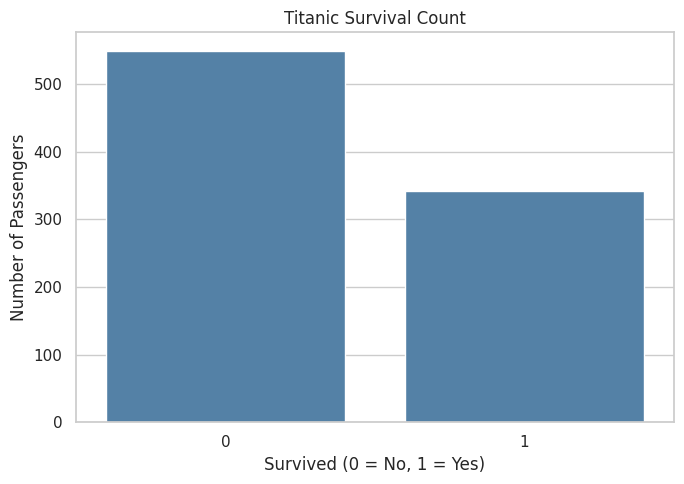

In [7]:
plt.figure(figsize=(7, 5))
sns.countplot(data=clean, x="Survived", color="steelblue")
plt.title("Titanic Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_survival_count.png", dpi=180, bbox_inches="tight")
plt.show()

## 5. Survival by Gender

Gender is one of the strongest differences in the dataset. The chart below compares survival rates directly.

In [8]:
sex_survival = (clean.groupby("Sex")["Survived"].mean() * 100).sort_values(ascending=False)
sex_survival

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

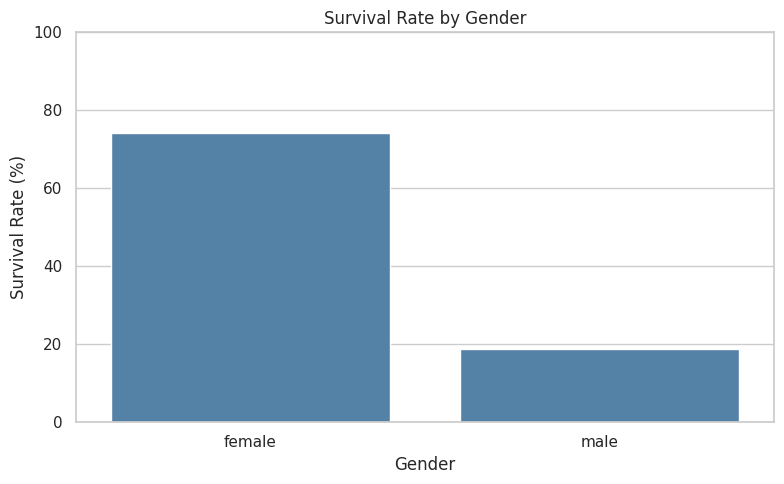

In [9]:
plt.figure(figsize=(8, 5))
sns.barplot(x=sex_survival.index, y=sex_survival.values, color="steelblue")
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_survival_by_gender.png", dpi=180, bbox_inches="tight")
plt.show()

### Finding

Female passengers had a much higher survival rate than male passengers in this dataset.

## 6. Survival by Passenger Class

Passenger class is a proxy for socioeconomic position and access to resources on the ship.

In [10]:
class_survival = (clean.groupby("Pclass")["Survived"].mean() * 100).round(2)
class_survival

Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64

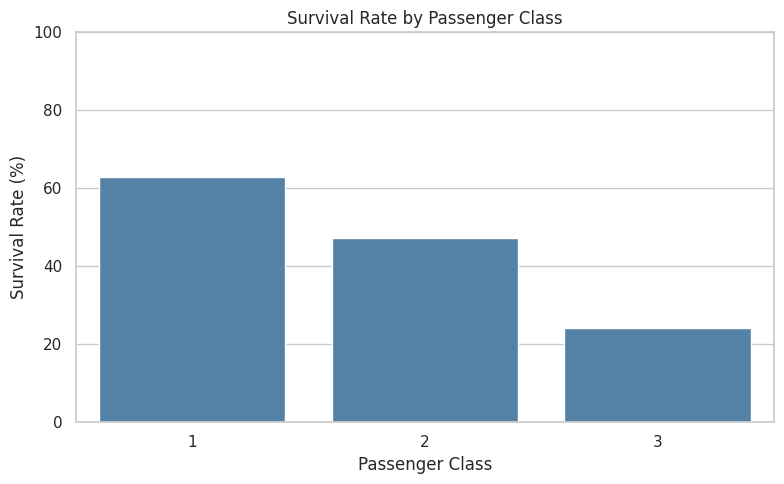

In [11]:
plt.figure(figsize=(8, 5))
sns.barplot(x=class_survival.index.astype(str), y=class_survival.values, color="steelblue")
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_survival_by_class.png", dpi=180, bbox_inches="tight")
plt.show()

### Finding

Survival decreased substantially as passenger class moved from 1st class to 3rd class.

## 7. Gender + Passenger Class

Looking at gender and class together gives a clearer picture than either factor alone.

In [12]:
sex_class_survival = (clean.groupby(["Pclass", "Sex"])["Survived"].mean() * 100).round(2).reset_index()
sex_class_survival

,Pclass,Sex,Survived
0,1,female,96.81
1,1,male,36.89
2,2,female,92.11
3,2,male,15.74
4,3,female,50.00
5,3,male,13.54


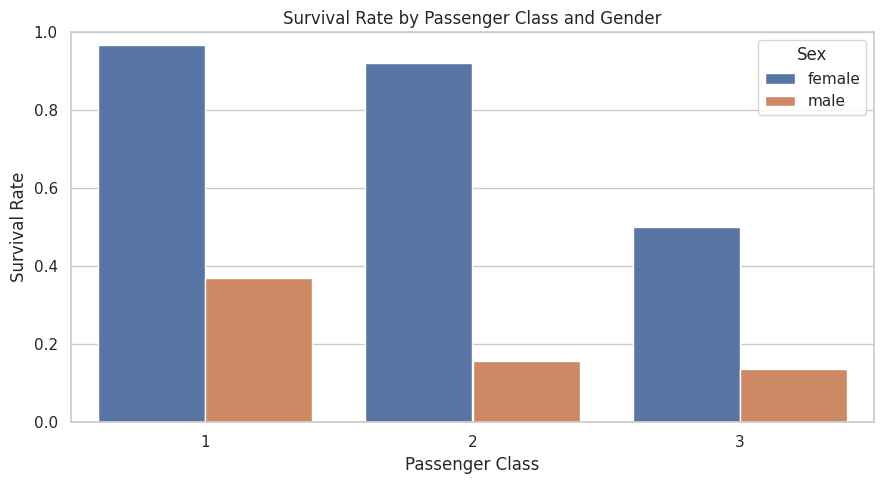

In [13]:
plt.figure(figsize=(9, 5))
sns.barplot(data=clean, x="Pclass", y="Survived", hue="Sex", errorbar=None, palette="deep")
plt.title("Survival Rate by Passenger Class and Gender")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_survival_by_class_gender.png", dpi=180, bbox_inches="tight")
plt.show()

## 8. Family Travel and Survival

`IsAlone` separates passengers traveling alone from passengers traveling with at least one family member.

In [14]:
alone_survival = (clean.groupby("IsAlone")["Survived"].mean() * 100).round(2)
alone_survival

IsAlone
Alone          30.35
With Family    50.56
Name: Survived, dtype: float64

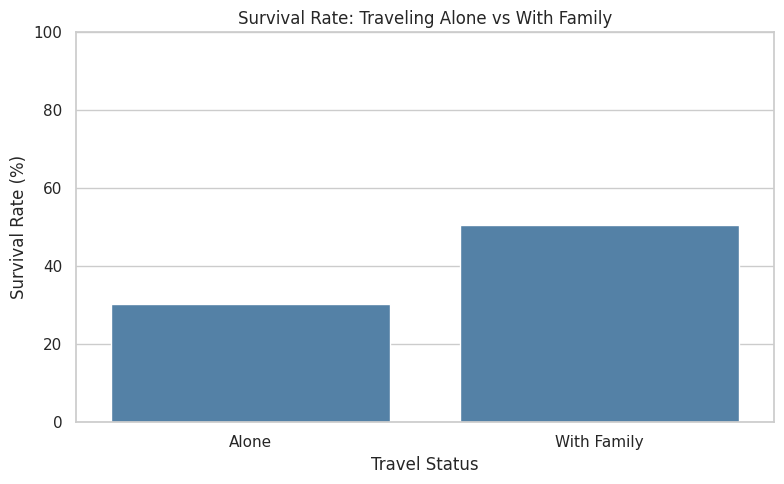

In [15]:
plt.figure(figsize=(8, 5))
sns.barplot(x=alone_survival.index, y=alone_survival.values, color="steelblue")
plt.title("Survival Rate: Traveling Alone vs With Family")
plt.xlabel("Travel Status")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_survival_family_status.png", dpi=180, bbox_inches="tight")
plt.show()

### Finding

Passengers traveling with family members had a higher survival rate than passengers traveling alone in this dataset.

## 9. Age and Survival

Age can be explored using both the numerical distribution and age groups.

In [16]:
age_group_survival = (clean.groupby("AgeGroup", observed=True)["Survived"].mean() * 100).round(2)
age_group_survival

AgeGroup
Child          57.97
Teen           42.86
Young Adult    35.33
Adult          40.00
Senior         22.73
Name: Survived, dtype: float64

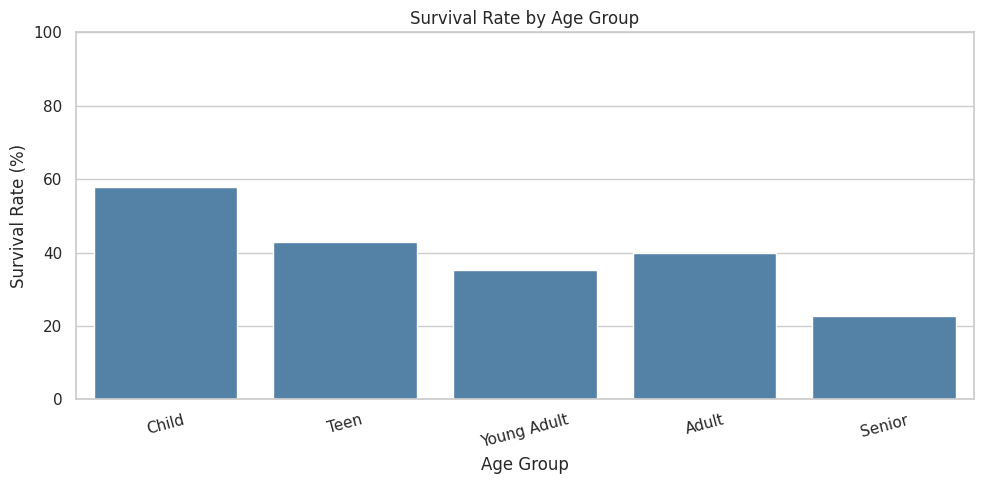

In [17]:
plt.figure(figsize=(10, 5))
sns.barplot(x=age_group_survival.index.astype(str), y=age_group_survival.values, color="steelblue")
plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")
plt.ylim(0, 100)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_survival_by_age_group.png", dpi=180, bbox_inches="tight")
plt.show()

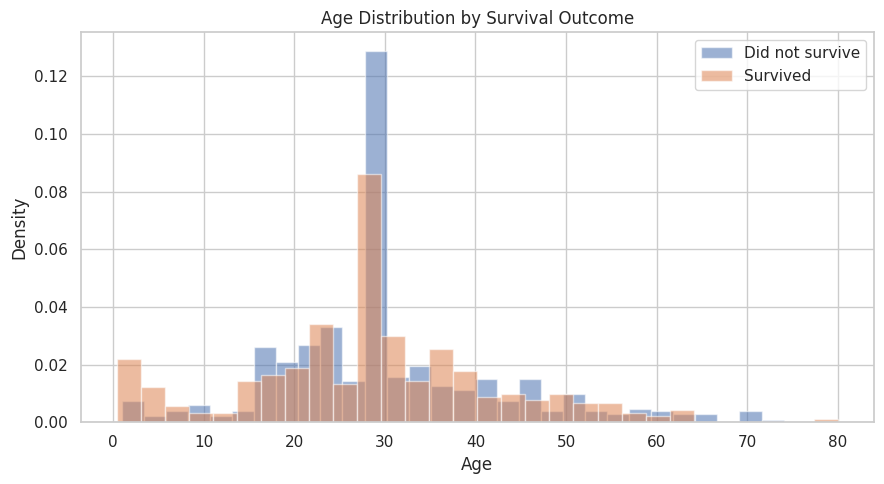

In [18]:
plt.figure(figsize=(9, 5))
plt.hist(clean.loc[clean["Survived"].eq(0), "Age"], bins=30, density=True, alpha=0.55, label="Did not survive")
plt.hist(clean.loc[clean["Survived"].eq(1), "Age"], bins=30, density=True, alpha=0.55, label="Survived")
plt.title("Age Distribution by Survival Outcome")
plt.xlabel("Age")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "07_age_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

### Finding

Children had a relatively high survival rate compared with several older age groups, although age alone does not explain survival.

## 10. Fare and Survival

Fare is another socioeconomic indicator. The box plot compares fare distributions for passengers who survived and did not survive.

In [19]:
fare_stats = clean.groupby("Survived")["Fare"].agg(["count", "mean", "median", "min", "max"]).round(2)
fare_stats

,count,mean,median,min,max
Survived,,,,,
0,549,22.12,10.5,0.0,263.00
1,342,48.40,26.0,0.0,512.33


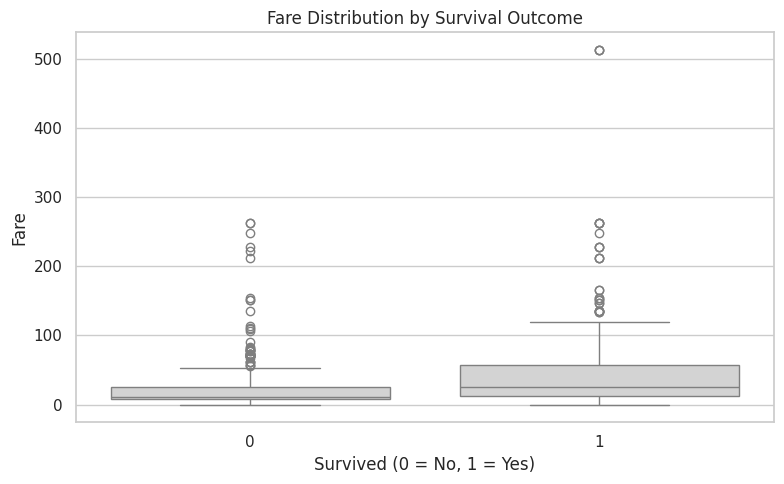

In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=clean, x="Survived", y="Fare", color="lightgray")
plt.title("Fare Distribution by Survival Outcome")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Fare")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "08_fare_by_survival.png", dpi=180, bbox_inches="tight")
plt.show()

## 11. Correlation Snapshot

Correlation does not prove causation, but it can help identify numerical variables associated with the outcome.

In [21]:
num_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize"]
corr = clean[num_cols].corr(numeric_only=True)
corr["Survived"].sort_values(ascending=False)

Survived      1.000000
Fare          0.257307
Parch         0.081629
FamilySize    0.016639
SibSp        -0.035322
Age          -0.064910
Pclass       -0.338481
Name: Survived, dtype: float64

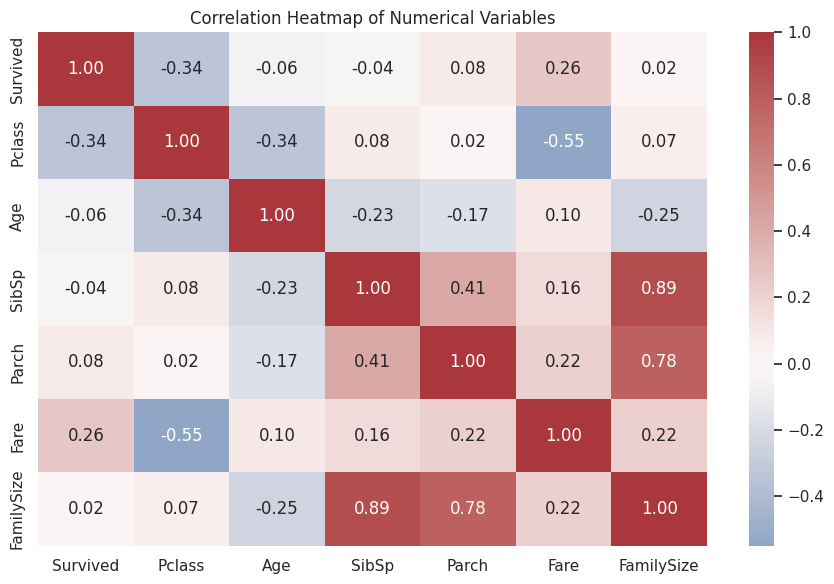

In [22]:
plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "09_correlation_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

## 12. Key Insights

### Main observations

1. **Overall survival:** The dataset survival rate is about **38.4%**.
2. **Gender:** Female passengers had a much higher survival rate than male passengers.
3. **Passenger class:** First-class passengers had substantially better survival outcomes than third-class passengers.
4. **Family travel:** Passengers traveling with family had a higher survival rate than passengers traveling alone.
5. **Age:** Children had a relatively favorable survival rate, but age interacts with other characteristics.
6. **Fare:** Survivors generally paid higher fares, which is consistent with the relationship between fare and passenger class.

These are descriptive findings from the dataset and should not be interpreted as causal proof.

In [23]:
# Compact final summary table
final_summary = pd.DataFrame({
    "Metric": [
        "Overall survival rate",
        "Female survival rate",
        "Male survival rate",
        "1st class survival rate",
        "2nd class survival rate",
        "3rd class survival rate",
        "Traveling alone survival rate",
        "Traveling with family survival rate",
    ],
    "Value": [
        f"{clean['Survived'].mean()*100:.2f}%",
        f"{clean.loc[clean['Sex'].eq('female'), 'Survived'].mean()*100:.2f}%",
        f"{clean.loc[clean['Sex'].eq('male'), 'Survived'].mean()*100:.2f}%",
        f"{clean.loc[clean['Pclass'].eq(1), 'Survived'].mean()*100:.2f}%",
        f"{clean.loc[clean['Pclass'].eq(2), 'Survived'].mean()*100:.2f}%",
        f"{clean.loc[clean['Pclass'].eq(3), 'Survived'].mean()*100:.2f}%",
        f"{clean.loc[clean['IsAlone'].eq('Alone'), 'Survived'].mean()*100:.2f}%",
        f"{clean.loc[clean['IsAlone'].eq('With Family'), 'Survived'].mean()*100:.2f}%",
    ]
})
final_summary

,Metric,Value
0,Overall survival rate,38.38%
1,Female survival rate,74.20%
2,Male survival rate,18.89%
3,1st class survival rate,62.96%
4,2nd class survival rate,47.28%
5,3rd class survival rate,24.24%
6,Traveling alone survival rate,30.35%
7,Traveling with family survival rate,50.56%


## 13. Conclusion

This mini project demonstrates a complete introductory data-science workflow: loading a real-world dataset, understanding its structure, handling missing values, engineering useful features, performing exploratory analysis, visualizing patterns, and communicating findings.

The strongest descriptive patterns are the differences in survival by **gender** and **passenger class**, with additional variation associated with **family status, age, and fare**.

## 14. Next Steps

A natural extension would be to build a classification model using selected features, compare logistic regression with tree-based models, and evaluate the model with accuracy, precision, recall, F1-score, and ROC-AUC.